## Prueba Técnica — Científico de Datos para Soluciones con IA
### Equipo Canales Digitales

Maria Isabel Rios López
CC 1000872314

marioslo@unal.edu.co - 3147098354

In [1]:
# Librerías necesarias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import json
import os

### Exploración inicial de los datos

In [2]:
import os

data_dir = 'datos'

# Carga de datos
customers     = pd.read_csv(os.path.join(data_dir, 'customers_dataset.csv'))
geo           = pd.read_csv(os.path.join(data_dir, 'geolocation_dataset.csv'))
orders        = pd.read_csv(os.path.join(data_dir, 'orders_dataset.csv'))
order_items   = pd.read_csv(os.path.join(data_dir, 'order_items_dataset.csv'))
payments      = pd.read_csv(os.path.join(data_dir, 'order_payments_dataset.csv'))
reviews       = pd.read_csv(os.path.join(data_dir, 'order_reviews_dataset.csv'))
products      = pd.read_csv(os.path.join(data_dir, 'products_dataset.csv'))
translations  = pd.read_csv(os.path.join(data_dir, 'product_category_name_translation.csv'))
sellers       = pd.read_csv(os.path.join(data_dir, 'sellers_dataset.csv'))

# Convertir timestamps
date_cols = ['order_purchase_timestamp','order_approved_at',
             'order_delivered_carrier_date','order_delivered_customer_date',
             'order_estimated_delivery_date']
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

print('Datasets cargados:')
datasets = {'customers': customers, 'orders': orders, 'order_items': order_items,
            'payments': payments, 'reviews': reviews, 'products': products,
            'geolocation': geo, 'sellers': sellers, 'translations': translations}
for name, df in datasets.items():
    print(f'  {name:20s}: {df.shape[0]:>8,} filas x {df.shape[1]} columnas')

Datasets cargados:
  customers           :   99,441 filas x 5 columnas
  orders              :   99,441 filas x 8 columnas
  order_items         :  112,650 filas x 7 columnas
  payments            :  103,886 filas x 5 columnas
  reviews             :   99,224 filas x 7 columnas
  products            :   32,951 filas x 9 columnas
  geolocation         : 1,000,163 filas x 5 columnas
  sellers             :    3,095 filas x 4 columnas
  translations        :       71 filas x 2 columnas


In [3]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
customers.tail()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS
99440,274fa6071e5e17fe303b9748641082c8,84732c5050c01db9b23e19ba39899398,6703,cotia,SP


**Sobre la base customers**

Es un conjunto de datos que recopila información de clientes que incluye variables de identificación y ubicación geográfica. Cuenta con 99.441 registros, donde cada fila representa un cliente identificado mediante customer_id y customer_unique_id. Además, contiene variables como código postal, ciudad y estado (abreviado por siglas correspondientes al estado geografico correspondiente), que permiten realizar segmentaciones y análisis geográficos de los clientes.

In [5]:
geo.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [6]:
geo.tail()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
1000158,99950,-28.068639,-52.010705,tapejara,RS
1000159,99900,-27.877125,-52.224882,getulio vargas,RS
1000160,99950,-28.071855,-52.014716,tapejara,RS
1000161,99980,-28.388932,-51.846871,david canabarro,RS
1000162,99950,-28.070104,-52.018658,tapejara,RS


**Sobre la base geo**

Es un conjunto de datos que recopila información georreferenciada de los clientes, incluyendo coordenadas geográficas (latitud y longitud), ciudad y estado. Cuenta con 1.000.163 registros, donde cada fila representa una ubicación específica asociada a un código postal, lo que permite realizar análisis espaciales, segmentación geográfica y estudios de distribución territorial de los clientes.

In [7]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [8]:
orders.tail()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15
99440,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-03-08 20:57:30,2018-03-09 11:20:28,2018-03-09 22:11:59,2018-03-16 13:08:30,2018-04-03


**Sobre la base orders**

La base de datos recopila información sobre las órdenes realizadas por los clientes, donde cada pedido está identificado de manera única mediante la variable *order_id*. Cuenta con 99.441 registros. Incluye además el estado del pedido y las fechas clave del proceso de compra y entrega, lo que permite analizar tiempos de aprobación, despacho y cumplimiento logístico frente a las fechas estimadas.

In [9]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [10]:
order_items.tail()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72
112649,fffe41c64501cc87c801fd61db3f6244,1,350688d9dc1e75ff97be326363655e01,f7ccf836d21b2fb1de37564105216cc1,2018-06-12 17:10:13,43.00,12.79


**Sobre la base order_items**

La base de datos recopila información sobre los productos incluidos en cada pedido, donde cada registro está asociado a un *order_id* y se diferencia mediante *product_id*. Cuenta con 112.650 registros. Incluye además identificadores de la orden y del vendedor, junto con variables como precio, costo de envío y fecha límite de envio, lo que permite analizar el detalle de las órdenes y la dinámica de ventas y logística.

In [11]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [12]:
payments.tail()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54
103885,28bbae6599b09d39ca406b747b6632b1,1,boleto,1,191.58


**Sobre la base payments**

La base de datos recopila información sobre los pagos asociados a cada pedido, donde cada registro está vinculado a un *order_id* y se diferencia mediante *payment_sequential*. Cuenta con 103.886 registros. Incluye variables como el tipo de pago, número de cuotas y valor pagado, lo que permite analizar los métodos de pago y el comportamiento financiero de los clientes.

In [13]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [14]:
reviews.tail()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13
99223,efe49f1d6f951dd88b51e6ccd4cc548f,90531360ecb1eec2a1fbb265a0db0508,1,NaN,"meu produto chegou e ja tenho que devolver, po...",2017-07-03 00:00:00,2017-07-03 21:01:49


**Sobre la base reviews**

Es un conjunto de datos que recopila las evaluaciones de los pedidos, incluyendo puntuaciones y comentarios de los clientes. Cuenta con 99.224 donde cada fila representa una reseña única identificada por *review_id* y vinculada a una compra mediante *order_id*. Además, contiene variables como la calificación *review_score*, fechas de creación y respuesta, que permiten analizar la satisfacción del cliente y los tiempos de atención.

In [15]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [16]:
products.tail()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0
32950,106392145fca363410d287a815be6de4,cama_mesa_banho,58.0,309.0,1.0,2083.0,12.0,2.0,7.0


**Sobre la base products**

Es un conjunto de datos que recopila información técnica y logística de los artículos del catálogo. Cuenta con 32.951 donde cada fila representa un producto único identificado por *product_id*. Además, contiene variables como la categoría *product_category_name*, dimensiones físicas (peso, largo, alto y ancho), que permiten clasificar el inventario y analizar los requerimientos de envío.

In [17]:
translations.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [18]:
translations.tail()

,product_category_name,product_category_name_english
66,flores,flowers
67,artes_e_artesanato,arts_and_craftmanship
68,fraldas_higiene,diapers_and_hygiene
69,fashion_roupa_infanto_juvenil,fashion_childrens_clothes
70,seguros_e_servicos,security_and_services


**Sobre la base translations**

Es un conjunto de datos que funciona como un diccionario de traducción para las categorías del catálogo. Cuenta con 71 registros donde cada fila relaciona el nombre original de la categoría en portugués *product_category_name* con su correspondiente traducción al inglés *product_category_name_english*, lo que permite estandarizar la información.

In [19]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [20]:
sellers.tail()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
3090,98dddbc4601dd4443ca174359b237166,87111,sarandi,PR
3091,f8201cab383e484733266d1906e2fdfa,88137,palhoca,SC
3092,74871d19219c7d518d0090283e03c137,4650,sao paulo,SP
3093,e603cf3fec55f8697c9059638d6c8eb5,96080,pelotas,RS
3094,9e25199f6ef7e7c347120ff175652c3b,12051,taubate,SP


**Sobre la base sellers**

Es un conjunto de datos que recopila información sobre los vendedores registrados en la plataforma. Cuenta con 3.095 registros donde cada fila representa un proveedor único identificado por *seller_id*. Además, contiene variables de ubicación geográfica como el prefijo del código postal *seller_zip_code_prefix*, la ciudad *seller_city* y el estado *seller_state*.

In [21]:
resumenes = {}

for name, df in datasets.items():
    print(f"\n{'='*50}")
    print(f"Resumen de la base de datos: {name.upper()}")
    print(f"{'='*50}")
    
    # Conteo de valores NA y Null 
    na_count = df.isna().sum()
    null_count = df.isnull().sum()
    
    # Extraer info de tipos de datos 
    dtypes = df.dtypes
    
    # Número de valores no nulos 
    non_null_count = df.count()

    # Construir tabla resumen 
    resumen = pd.DataFrame({
        'dtype': dtypes,
        'non_null_count': non_null_count,
        'na_count': na_count, 
        'null_count': null_count
    })
    
    # Guardar en el diccionario de resúmenes
    resumenes[name] = resumen
    
    # Imprimir el resultado
    print(resumen)


Resumen de la base de datos: CUSTOMERS
                           dtype  non_null_count  na_count  null_count
customer_id               object           99441         0           0
customer_unique_id        object           99441         0           0
customer_zip_code_prefix   int64           99441         0           0
customer_city             object           99441         0           0
customer_state            object           99441         0           0

Resumen de la base de datos: ORDERS
                                        dtype  non_null_count  na_count  \
order_id                               object           99441         0   
customer_id                            object           99441         0   
order_status                           object           99441         0   
order_purchase_timestamp       datetime64[ns]           99441         0   
order_approved_at              datetime64[ns]           99281       160   
order_delivered_carrier_date   datetime64[ns]  

Aunque hay presencia de valores NA, se opta por conservarlos sin realizar procesos de imputación ni eliminación, dado que estos no representan errores, sino situaciones propias de la operación del negocio. Por ejemplo, un comentario vacío corresponde a un cliente que decidió no registrar opinión. La imputación de estos valores podría distorsionar las métricas y afectar la interpretación de los resultados. En consecuencia, la estrategia adoptada consiste en filtrar los análisis considerando únicamente la información necesaria.

In [22]:
# Análisis exploratorio de la base de órdenes 
print('=== Distribución de estados de órdenes ===')
print(orders['order_status'].value_counts())

print('\n=== Rango temporal del dataset ===')
print(f'Primera orden: {orders["order_purchase_timestamp"].min().date()}')
print(f'Última orden:  {orders["order_purchase_timestamp"].max().date()}')

delivered_ids = orders[orders['order_status'] == 'delivered']['order_id']
print(f'\nÓrdenes entregadas: {len(delivered_ids):,} ({len(delivered_ids)/len(orders)*100:.1f}%)')

=== Distribución de estados de órdenes ===
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

=== Rango temporal del dataset ===
Primera orden: 2016-09-04
Última orden:  2018-10-17

Órdenes entregadas: 96,478 (97.0%)


En general, se observa que la gran mayoría de las órdenes corresponden a pedidos entregados, representando el 97% del total, lo que indica un alto nivel de cumplimiento en el proceso logístico. Los demás estados tienen diferente partipación, siendo *shipped*, *canceled* y *unavailable* los más relevantes dentro de este grupo.

Por otra parte, el rango temporal del dataset abarca desde septiembre de 2016 hasta octubre de 2018, lo que proporciona una ventana de análisis suficientemente amplia para identificar patrones en el comportamiento de las órdenes.

In [23]:
# Análisis exploratorio de la base de pagos
print('=== Distribución de medios de pago ===')
print(payments['payment_type'].value_counts())
print(f'\nTotal registros de pago:  {len(payments):,}')
print(f'Órdenes únicas con pago: {payments["order_id"].nunique():,}')
print(f'Órdenes con múltiples métodos: {(payments.groupby("order_id")["payment_type"].nunique() > 1).sum():,}')

=== Distribución de medios de pago ===
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

Total registros de pago:  103,886
Órdenes únicas con pago: 99,440
Órdenes con múltiples métodos: 2,246


En general, se observa la distribución de los diferentes medios de pago utilizados por los clientes, lo que permite identificar cuáles son los más frecuentes dentro del dataset. Asimismo, el número total de registros de pago es superior al número de órdenes únicas, lo que indica que una misma orden puede estar asociada a uno o varios pagos. Adicionalmente, se identifica que existe un conjunto de órdenes en las que se utilizaron múltiples métodos de pago, lo que refleja cierta flexibilidad en el proceso de compra y evidencia comportamientos más complejos por parte de algunos clientes al momento de realizar sus transacciones.

In [24]:
# Análisis exploratorio de review_score
print('=== Distribución de puntajes ===')
print(reviews['review_score'].value_counts().sort_index())
print('\n=== Estadísticas descriptivas ===')
print(reviews['review_score'].describe().round(2))

print('\n=== Segmentación positivo / neutro / negativo ===')
bins = {
    'Negativo (1-2)': reviews['review_score'].isin([1, 2]).sum(),
    'Neutro    (3)  ': reviews['review_score'].eq(3).sum(),
    'Positivo  (4-5)': reviews['review_score'].isin([4, 5]).sum()
}
total = len(reviews)
for label, count in bins.items():
    print(f'{label}: {count:,} ({count/total*100:.1f}%)')

print('\n=== % de reseñas con comentario por puntaje ===')
reviews['tiene_comentario'] = reviews['review_comment_message'].notna()
print(reviews.groupby('review_score')['tiene_comentario']
      .mean().mul(100).round(2).astype(str) + '%')

=== Distribución de puntajes ===
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

=== Estadísticas descriptivas ===
count    99224.00
mean         4.09
std          1.35
min          1.00
25%          4.00
50%          5.00
75%          5.00
max          5.00
Name: review_score, dtype: float64

=== Segmentación positivo / neutro / negativo ===
Negativo (1-2): 14,575 (14.7%)
Neutro    (3)  : 8,179 (8.2%)
Positivo  (4-5): 76,470 (77.1%)

=== % de reseñas con comentario por puntaje ===
review_score
1    76.55%
2    68.07%
3    43.49%
4    31.22%
5    35.85%
Name: tiene_comentario, dtype: object


En general, se observa una clara concentración de los puntajes en valores altos, con una media de 4.09 y una mediana de 5, lo que indica una alta satisfacción por parte de los clientes. Aproximadamente el 77.1% de las reseñas son positivas (4–5), mientras que las negativas representan el 14.7% y las neutrales el 8.2%, evidenciando una percepción mayoritariamente favorable del servicio. Adicionalmente, se identifica que los clientes tienden a dejar más comentarios cuando la experiencia es negativa, alcanzando el 76.55% en los puntajes más bajos, mientras que en calificaciones altas la proporción de comentarios es considerablemente menor. Esto sugiere que las reseñas escritas están más asociadas a experiencias que no cumplen las expectativas.

## Punto 1 — Top 5 Productos por Volumen e Ingresos

Para resolver el punto, se filtran únicamente las órdenes con status *delivered*. Se realiza un join entre *order_items*, *products* y *product_category_name_translation* para obtener las categorías en inglés. Se agrupa por categoría y se calcula (a) número de unidades vendidas y (b) suma de ingresos por precio de producto.

In [25]:
# Join items con categorías
items = order_items[order_items['order_id'].isin(delivered_ids)].copy()
items = items.merge(products[['product_id','product_category_name']], on='product_id', how='left')
items = items.merge(translations, on='product_category_name', how='left')
items['category'] = items['product_category_name_english'].fillna(items['product_category_name'])

# Top 5 por VOLUMEN
top5_vol = (items.groupby('category')
                 .size()
                 .reset_index(name='units_sold')
                 .sort_values('units_sold', ascending=False)
                 .head(5)
                 .reset_index(drop=True))
top5_vol.index += 1

# Top 5 por INGRESOS 
top5_rev = (items.groupby('category')['price']
                 .sum()
                 .reset_index(name='total_ganacia')
                 .sort_values('total_ganacia', ascending=False)
                 .head(5)
                 .reset_index(drop=True))
top5_rev.index += 1

print('TOP 5 CATEGORÍAS POR VOLUMEN (unidades vendidas):')
print(top5_vol.to_string())
print()
print('TOP 5 CATEGORÍAS POR INGRESOS (ganancia total BRL):')
print(top5_rev.assign(total_ganacia=top5_rev['total_ganacia'].map('${:,.2f}'.format)).to_string())

TOP 5 CATEGORÍAS POR VOLUMEN (unidades vendidas):
                category  units_sold
1         bed_bath_table       10953
2          health_beauty        9465
3         sports_leisure        8431
4        furniture_decor        8160
5  computers_accessories        7644

TOP 5 CATEGORÍAS POR INGRESOS (ganancia total BRL):
                category  total_ganacia
1          health_beauty  $1,233,131.72
2          watches_gifts  $1,166,176.98
3         bed_bath_table  $1,023,434.76
4         sports_leisure    $954,852.55
5  computers_accessories    $888,724.61


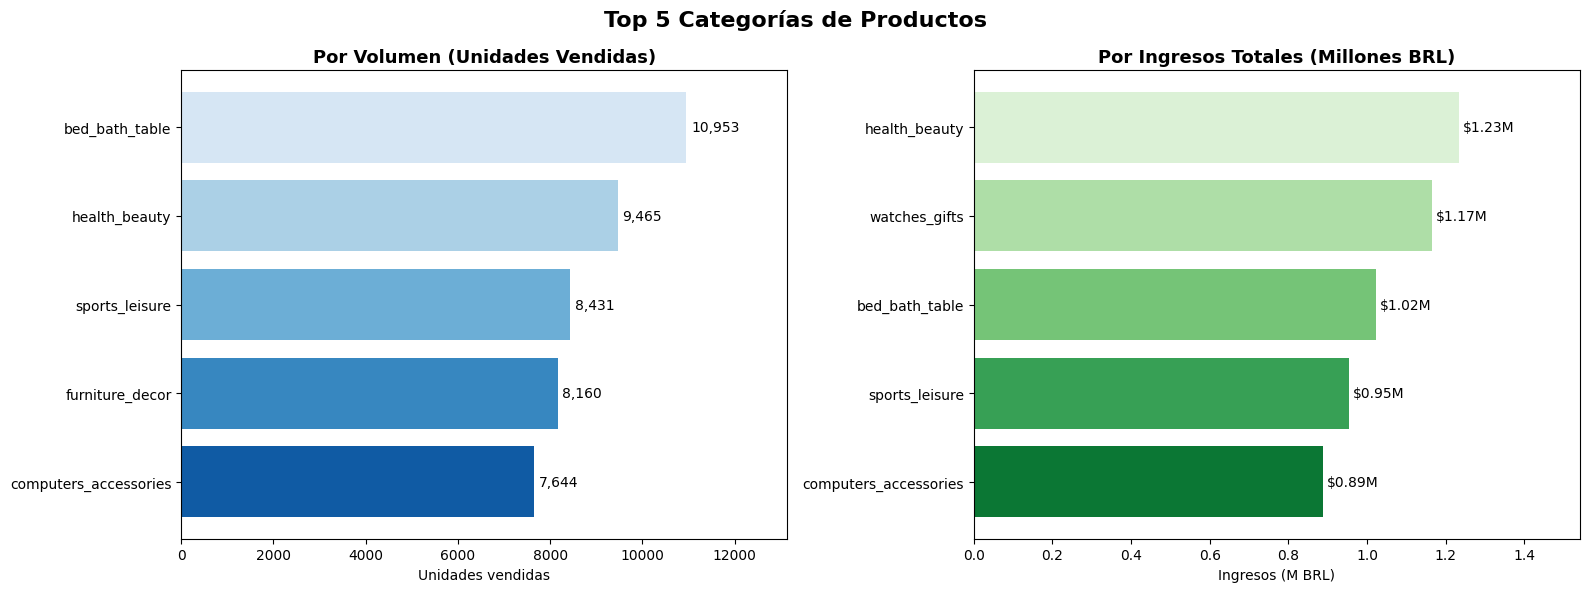

In [26]:
# Gráfica punto 1
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top 5 Categorías de Productos', fontsize=16, fontweight='bold')

colors_vol = sns.color_palette('Blues_r', 5)
colors_rev = sns.color_palette('Greens_r', 5)

# Volumen
bars1 = axes[0].barh(top5_vol['category'][::-1], top5_vol['units_sold'][::-1], color=colors_vol)
axes[0].set_title('Por Volumen (Unidades Vendidas)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Unidades vendidas')
for bar, val in zip(bars1, top5_vol['units_sold'][::-1]):
    axes[0].text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=10)
axes[0].set_xlim(0, top5_vol['units_sold'].max() * 1.2)

# Ingreso
bars2 = axes[1].barh(top5_rev['category'][::-1], top5_rev['total_ganacia'][::-1]/1e6, color=colors_rev)
axes[1].set_title('Por Ingresos Totales (Millones BRL)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Ingresos (M BRL)')
for bar, val in zip(bars2, top5_rev['total_ganacia'][::-1]):
    axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f'${val/1e6:.2f}M', va='center', fontsize=10)
axes[1].set_xlim(0, top5_rev['total_ganacia'].max()/1e6 * 1.25)

plt.tight_layout()
plt.show()

En general, se observa que las categorías con mayor volumen de ventas no necesariamente coinciden con aquellas que generan mayores ingresos. Por ejemplo, *bed_bath_table* lidera en unidades vendidas, pero es *health_beauty* la que encabeza en términos de ingresos, seguida de *watches_gifts*.

Esto sugiere que existen diferencias en los precios promedio entre categorías, donde algunas venden más volumen a menor precio, mientras que otras, con menor cantidad de unidades, logran mayores ingresos. En conjunto, estos resultados permiten identificar tanto categorías de alta rotación como aquellas de mayor valor económico dentro del negocio.

## Punto 2 — Mayor Dolor de Clientes

Para resolver el punto, se analizan las *order_reviews* con score 1 o 2 (14.7% del total). Se hace análisis de frecuencia de palabras clave en los comentarios (en portugués) para identificar temas recurrentes. Se cruza con categorías de productos para identificar cuáles tienen más quejas.

In [27]:
## === Dolor de clientes ===
# Reviews negativas
bad_reviews = reviews[reviews['review_score'] <= 2].copy()
print(f'Reviews totales: {len(reviews):,}')
print(f'Reviews negativas (score 1-2): {len(bad_reviews):,} ({len(bad_reviews)/len(reviews)*100:.1f}%)')

# Distribución de scores
score_dist = reviews['review_score'].value_counts().sort_index()

# Análisis de comentarios negativos
bad_with_comments = bad_reviews[bad_reviews['review_comment_message'].notna()]
all_comments = ' '.join(bad_with_comments['review_comment_message'].str.lower().fillna(''))

pain_keywords = {
    'Producto defectuoso / calidad': [ 'defeito', 'quebrado', 'danificado', 'qualidade', 'ruim'],
    'No entregado / no llegó':       ['não recebi', 'não chegou', 'nao chegou', 'nao recebi'],
    'Problemas de entrega (general)':['entrega'],
    'Demora / atraso':               ['demorou', 'atrasado', 'prazo', 'demora'],
    'Producto incorrecto':           ['diferente', 'errado', 'errada', 'outro', 'outra'],
    'Mal servicio al cliente':       ['atendimento', 'resposta', 'contato'],
}

pain_counts = {}
for pain, keywords in pain_keywords.items():
    pain_counts[pain] = sum(all_comments.count(k) for k in keywords)

print('\n=== Frecuencia de temas de dolor (en comentarios negativos) ===')
for pain, count in sorted(pain_counts.items(), key=lambda x: -x[1]):
    print(f'  {pain}: {count:,} menciones')

Reviews totales: 99,224
Reviews negativas (score 1-2): 14,575 (14.7%)

=== Frecuencia de temas de dolor (en comentarios negativos) ===
  No entregado / no llegó: 2,398 menciones
  Problemas de entrega (general): 1,974 menciones
  Producto incorrecto: 1,524 menciones
  Demora / atraso: 1,419 menciones
  Producto defectuoso / calidad: 1,026 menciones
  Mal servicio al cliente: 930 menciones


En general, aunque las reseñas negativas representan solo el 14.7% del total, permiten identificar que los principales puntos de dolor están asociados principalmente a la logística de entrega. Las mayores incidencias corresponden a pedidos no recibidos, problemas generales en la entrega y retrasos, lo que evidencia que la experiencia post-compra es un factor crítico.

Adicionalmente, se presentan inconvenientes como productos incorrectos y defectos de calidad, así como fallas en el servicio al cliente. En conjunto, estos resultados sugieren que las principales oportunidades de mejora se concentran en la gestión logística y en el control de calidad, aspectos clave para fortalecer la satisfacción del cliente.

### Impacto de entrega tardía

In [28]:
# === Impacto de entrega tardía en el score ===
delivered_orders = orders[orders['order_status'] == 'delivered'].copy()
delivered_orders['late'] = (delivered_orders['order_delivered_customer_date'] >
                             delivered_orders['order_estimated_delivery_date'])

late_rate = delivered_orders['late'].mean() * 100
print(f'Tasa de entregas tardías: {late_rate:.1f}%')

reviews_with_late = reviews.merge(delivered_orders[['order_id','late']], on='order_id', how='left')
score_by_delivery = reviews_with_late.groupby('late')['review_score'].agg(['mean','count'])
score_by_delivery.index = ['A tiempo', 'Tardía']
print('\nScore promedio según tipo de entrega:')
print(score_by_delivery.round(3))

# Top categorías con más reviews negativas
bad_orders = bad_reviews.merge(order_items[['order_id','product_id']], on='order_id', how='left')
bad_orders = bad_orders.merge(products[['product_id','product_category_name']], on='product_id', how='left')
bad_orders = bad_orders.merge(translations, on='product_category_name', how='left')
bad_orders['category'] = bad_orders['product_category_name_english'].fillna(bad_orders['product_category_name'])

top_bad = (bad_orders.groupby('category')
                     .size()
                     .reset_index(name='bad_reviews')
                     .sort_values('bad_reviews', ascending=False)
                     .head(8)
                     .reset_index(drop=True))
top_bad.index += 1
print('\nTop 8 categorías con más reviews negativas:')
print(top_bad.to_string())

Tasa de entregas tardías: 8.1%

Score promedio según tipo de entrega:
           mean  count
A tiempo  4.294  88661
Tardía    2.566   7700

Top 8 categorías con más reviews negativas:
                category  bad_reviews
1         bed_bath_table         2112
2        furniture_decor         1621
3  computers_accessories         1461
4          health_beauty         1321
5         sports_leisure         1260
6             housewares         1086
7          watches_gifts          967
8              telephony          761


En general, se observa que, aunque la tasa de entregas tardías es relativamente baja (8.1%), su impacto en la satisfacción del cliente es significativo. Las órdenes entregadas a tiempo presentan un puntaje promedio alto (4.29), mientras que las tardías disminuyen considerablemente a 2.57, evidenciando una fuerte relación entre el cumplimiento en los tiempos de entrega y la percepción del servicio.

Por otra parte, las categorías con mayor número de reseñas negativas coinciden en gran medida con aquellas de alto volumen de ventas, como *bed_bath_table*, *furniture_decor* y *computers_accessories*. Esto sugiere que, además de la logística, el volumen de transacciones también influye en la cantidad de incidencias. En conjunto, los resultados refuerzan la importancia de optimizar los tiempos de entrega y monitorear de cerca las categorías más demandadas para mejorar la experiencia del cliente.

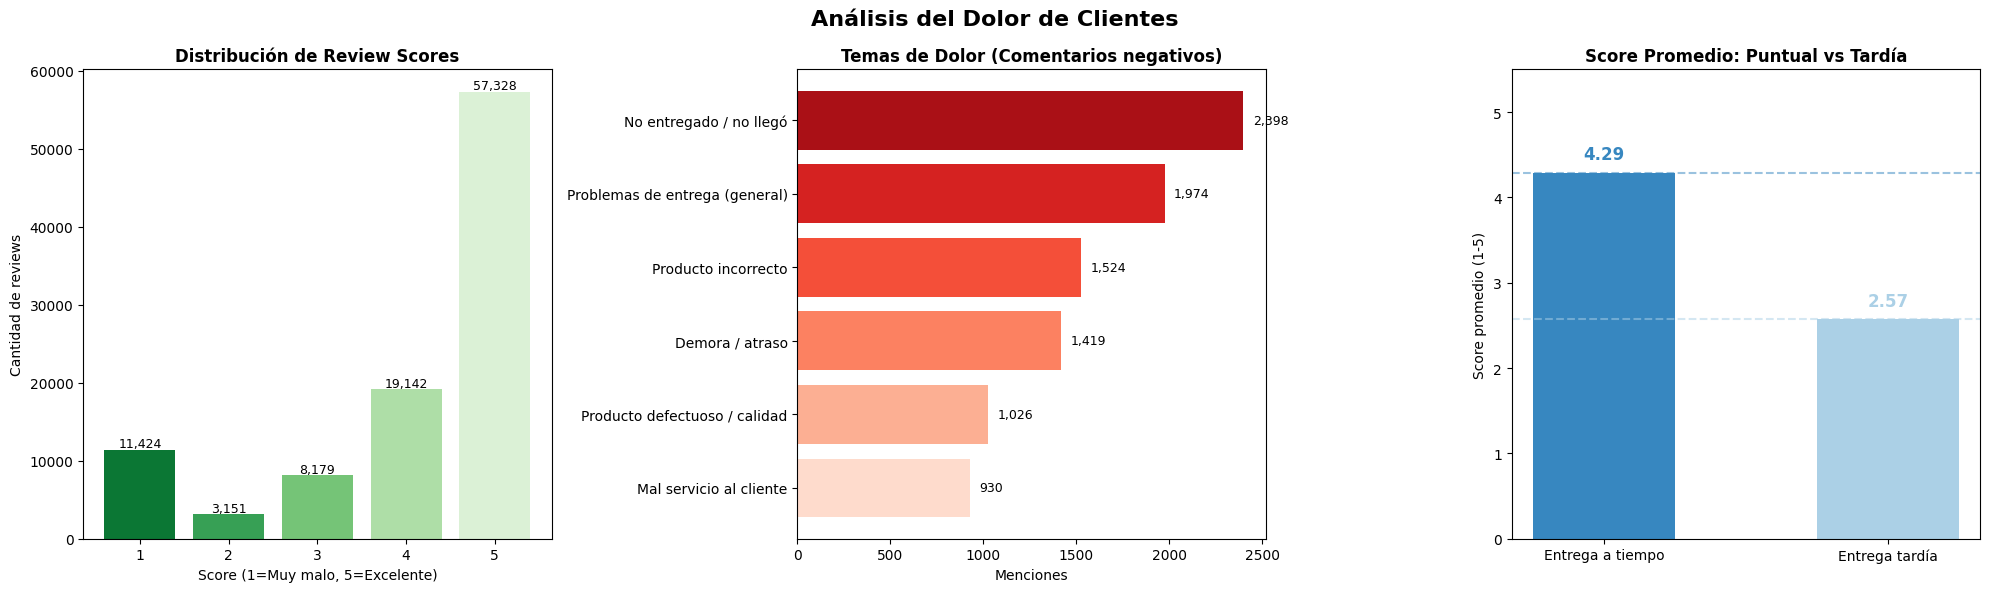

In [29]:
colors_green = sns.color_palette('Greens_r', 5)  
colors_reds = sns.color_palette('Reds_r', len(pain_counts)) 
colors_blues = sns.color_palette('Blues_r', 2) 

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Análisis del Dolor de Clientes', fontsize=16, fontweight='bold')

# 1. Distribución de scores
axes[0].bar(score_dist.index, score_dist.values, color=colors_green)
axes[0].set_title('Distribución de Review Scores', fontweight='bold')
axes[0].set_xlabel('Score (1=Muy malo, 5=Excelente)')
axes[0].set_ylabel('Cantidad de reviews')
for i, (x, y) in enumerate(zip(score_dist.index, score_dist.values)):
    axes[0].text(x, y + 300, f'{y:,}', ha='center', fontsize=9)

# 2. Temas de dolor 
pain_df = pd.DataFrame(list(pain_counts.items()), columns=['tema','menciones']).sort_values('menciones')
axes[1].barh(pain_df['tema'], pain_df['menciones'], color=sns.color_palette('Reds', len(pain_df)))
axes[1].set_title('Temas de Dolor (Comentarios negativos)', fontweight='bold')
axes[1].set_xlabel('Menciones')
for bar, val in zip(axes[1].patches, pain_df['menciones']):
    axes[1].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)

# 3. Score por tipo de entrega
delivery_labels = ['Entrega a tiempo', 'Entrega tardía']
delivery_values = [4.29, 2.57]
axes[2].bar(delivery_labels, delivery_values, color=colors_blues, width=0.5)
axes[2].set_title('Score Promedio: Puntual vs Tardía', fontweight='bold')
axes[2].set_ylabel('Score promedio (1-5)')
axes[2].set_ylim(0, 5.5)


axes[2].axhline(y=4.29, color=colors_blues[0], linestyle='--', alpha=0.5)
axes[2].axhline(y=2.57, color=colors_blues[1], linestyle='--', alpha=0.5)
axes[2].text(0, 4.45, '4.29', ha='center', fontsize=12, fontweight='bold', color=colors_blues[0])
axes[2].text(1, 2.73, '2.57', ha='center', fontsize=12, fontweight='bold', color=colors_blues[1])

plt.tight_layout()
plt.show()

En general, se observa que, aunque la satisfacción de los clientes es alta, los principales focos de insatisfacción están asociados a la logística de entrega, especialmente en casos de pedidos no recibidos o con retrasos. Asimismo, el cumplimiento en los tiempos de entrega resulta determinante, evidenciado en la fuerte caída del puntaje promedio cuando las órdenes se entregan tarde. 

En conjunto, los resultados sugieren que las principales oportunidades de mejora se concentran en la optimización de los procesos logísticos y el cumplimiento en los tiempos de entrega.

## Punto 3 — Segmentación de Clientes (RFM + K-Means)

Para el desarrollo del punto construye una matriz RFM (*Recency, Frequency, Monetary*) a nivel de *customer_unique_id*, donde:

    * Recency: mide qué tan reciente fue la última compra

    * Frequency: la cantidad de compras realizadas
    
    * Monetary: el valor total gastado por cliente

Este enfoque permite caracterizar el comportamiento y valor de cada cliente. Posteriormente, se aplica el algoritmo de *K-means* con escalado estándar, el cual agrupa a los clientes en segmentos homogéneos en función de estas variables. La elección de 4 clusters (K=4) se valida mediante el método del codo.

Se utiliza *customer_unique_id* en lugar de *customer_id*, dado que un mismo cliente puede estar asociado a múltiples identificadores transaccionales dentro del sistema. Para el cálculo de *Recency*, se toma como referencia el día siguiente a la última fecha de compra registrada en el dataset (2018-08-30).

In [30]:
# Preparar datos RFM
delivered_orders_full = orders[orders['order_status'] == 'delivered'].copy()
orders_with_customers = delivered_orders_full.merge(
    customers[['customer_id','customer_unique_id']], on='customer_id', how='left')

order_revenue = payments.groupby('order_id')['payment_value'].sum().reset_index(name='order_value')
orders_with_customers = orders_with_customers.merge(order_revenue, on='order_id', how='left')

# Fecha de referencia
ref_date = orders_with_customers['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f'Fecha de referencia (Recency): {ref_date.date()}')

# Calcular RFM
rfm = orders_with_customers.groupby('customer_unique_id').agg(
    recency   = ('order_purchase_timestamp', lambda x: (ref_date - x.max()).days),
    frequency = ('order_id', 'count'),
    monetary  = ('order_value', 'sum')
).reset_index()

print(f'\nClientes únicos analizados: {len(rfm):,}')
print('\nEstadísticas RFM:')
print(rfm[['recency','frequency','monetary']].describe().round(2))

Fecha de referencia (Recency): 2018-08-30

Clientes únicos analizados: 93,358

Estadísticas RFM:
        recency  frequency  monetary
count  93358.00   93358.00  93358.00
mean     237.94       1.03    165.20
std      152.59       0.21    226.31
min        1.00       1.00      0.00
25%      114.00       1.00     63.05
50%      219.00       1.00    107.78
75%      346.00       1.00    182.56
max      714.00      15.00  13664.08


En general, se observa que la base está compuesta por 93,358 clientes únicos, con una fecha de referencia para *Recency* del 2018-08-30. Los resultados evidencian que la mayoría de los clientes presenta una frecuencia de compra muy baja (mediana y percentiles en 1), lo que sugiere un comportamiento predominantemente ocasional.

Por otra parte, el gasto (*Monetary*) muestra una alta dispersión, con valores máximos considerablemente elevados frente a la mediana, lo que indica la existencia de un grupo reducido de clientes de alto valor. Asimismo, la variable *Recency* presenta una amplia variabilidad, reflejando tanto clientes recientes como otros con largos periodos de inactividad. En conjunto, estos patrones sugieren una base de clientes poco recurrente, con oportunidades claras para estrategias de fidelización y retención.

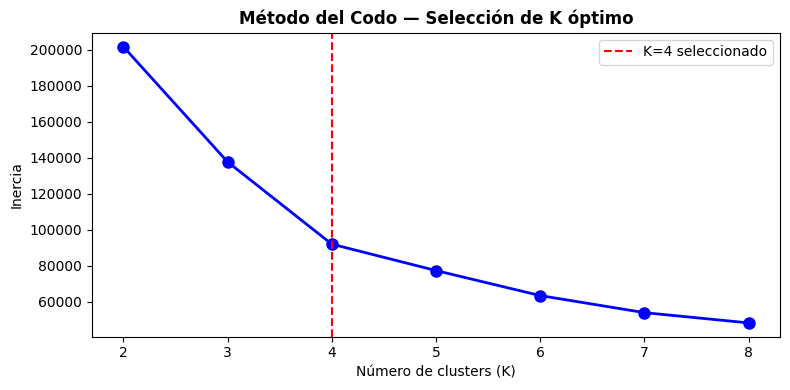

In [31]:
# Método del codo para K óptimo
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['recency','frequency','monetary']])

inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
ax.axvline(x=4, color='red', linestyle='--', label='K=4 seleccionado')
ax.set_title('Método del Codo — Selección de K óptimo', fontweight='bold')
ax.set_xlabel('Número de clusters (K)')
ax.set_ylabel('Inercia')
ax.legend()
plt.tight_layout()
plt.show()

Dada la gráfica de codo, se observa una reducción significativa de la inercia (La inercia en K-means es una medida de qué tan bien están agrupados los datos dentro de cada cluster. En términos simples, representa qué tan cerca están los puntos de su centroide) a medida que se incrementa el número de clusters, especialmente entre 2 y 4 grupos. Este comportamiento indica que, en ese rango, cada nuevo cluster aporta una mejora importante en la agrupación de los datos. A partir de K=4, la curva comienza a aplanarse, lo que sugiere que agregar más clusters genera mejoras cada vez menores. Es decir, aunque la inercia sigue disminuyendo, el aporte adicional ya no es tan relevante y podría implicar una segmentación innecesariamente compleja.

En este sentido, la elección de 4 clusters se considera adecuada, ya que permite obtener grupos bien diferenciados sin sobrecomplicar el modelo, facilitando además su interpretación y aplicación en estrategias de negocio.

In [32]:
# K-means con K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['cluster'] = kmeans.fit_predict(rfm_scaled)

# Resumen por cluster
cluster_summary = rfm.groupby('cluster').agg(
    n_customers  = ('customer_unique_id','count'),
    avg_recency  = ('recency','mean'),
    avg_frequency= ('frequency','mean'),
    avg_monetary = ('monetary','mean'),
    total_revenue= ('monetary','sum')
).round(2)

# Etiquetar segmentos manualmente basado en RFM
SEGMENT_LABELS = {
    0: 'En Riesgo de Abandono',  # Alta recency, baja freq, bajo monetary
    1: 'Clientes Fieles',      # Media recency, alta freq, medio monetary
    2: 'VIP / Alto Valor',     # Media recency, baja freq, muy alto monetary
    3: 'Nuevos / Recientes',  # Baja recency, baja freq, medio monetary
}

# Reasignar labels dinámicamente por características
cs = cluster_summary.copy()
labels_assigned = {}
# VIP: mayor monetary
vip = cs['avg_monetary'].idxmax()
labels_assigned[vip] = 'VIP / Alto Valor'
# Fieles: mayor frequency
cs2 = cs.drop(vip)
fieles = cs2['avg_frequency'].idxmax()
labels_assigned[fieles] = 'Clientes Fieles '
# Abandono: mayor recency
cs3 = cs2.drop(fieles)
dormidos = cs3['avg_recency'].idxmax()
labels_assigned[dormidos] = 'En Riesgo de Abandono'
# Nuevos: menor recency
for i in cs.index:
    if i not in labels_assigned:
        labels_assigned[i] = 'Nuevos / Recientes'

cluster_summary['segment'] = cluster_summary.index.map(labels_assigned)
rfm['segment'] = rfm['cluster'].map(labels_assigned)

print('=== SEGMENTOS DE CLIENTES ===')
for idx, row in cluster_summary.iterrows():
    pct = row['n_customers'] / len(rfm) * 100
    print(f"\n {row['segment']}")
    print(f"   Clientes: {int(row['n_customers']):,} ({pct:.1f}%)")
    print(f"   Recency: {row['avg_recency']:.0f} días | Freq: {row['avg_frequency']:.2f} compras | Ticket: ${row['avg_monetary']:.2f}")
    print(f"   Ganancia total: ${row['total_revenue']:,.0f}")

=== SEGMENTOS DE CLIENTES ===

 En Riesgo de Abandono
   Clientes: 37,526 (40.2%)
   Recency: 387 días | Freq: 1.00 compras | Ticket: $133.46
   Ganancia total: $5,008,136

 Clientes Fieles 
   Clientes: 2,772 (3.0%)
   Recency: 220 días | Freq: 2.11 compras | Ticket: $289.68
   Ganancia total: $802,994

 VIP / Alto Valor
   Clientes: 2,418 (2.6%)
   Recency: 239 días | Freq: 1.01 compras | Ticket: $1160.91
   Ganancia total: $2,807,072

 Nuevos / Recientes
   Clientes: 50,642 (54.2%)
   Recency: 128 días | Freq: 1.00 compras | Ticket: $134.36
   Ganancia total: $6,804,261


En general, se observa que la mayor parte de los clientes se concentra en los segmentos de **Nuevos/Recientes** (54.2%) y **En riesgo de abandono** (40.2%), ambos caracterizados por una baja frecuencia de compra, lo que indica un comportamiento predominantemente ocasional. Sin embargo, mientras los primeros han comprado recientemente, el segundo grupo presenta altos niveles de inactividad, representando una oportunidad clave para estrategias de reactivación.

Por otra parte, los segmentos de **Clientes fieles** y **VIP/Alto valor**, aunque representan una proporción reducida de la base, concentran un alto valor estratégico. Los clientes fieles destacan por su mayor frecuencia de compra, mientras que los VIP generan un alto ingreso por transacción, evidenciando su relevancia en términos de rentabilidad.

En conjunto, los resultados muestran una base amplia pero poco recurrente, con oportunidades claras tanto en retención de clientes recientes como en reactivación de clientes inactivos y fortalecimiento de los segmentos de mayor valor.

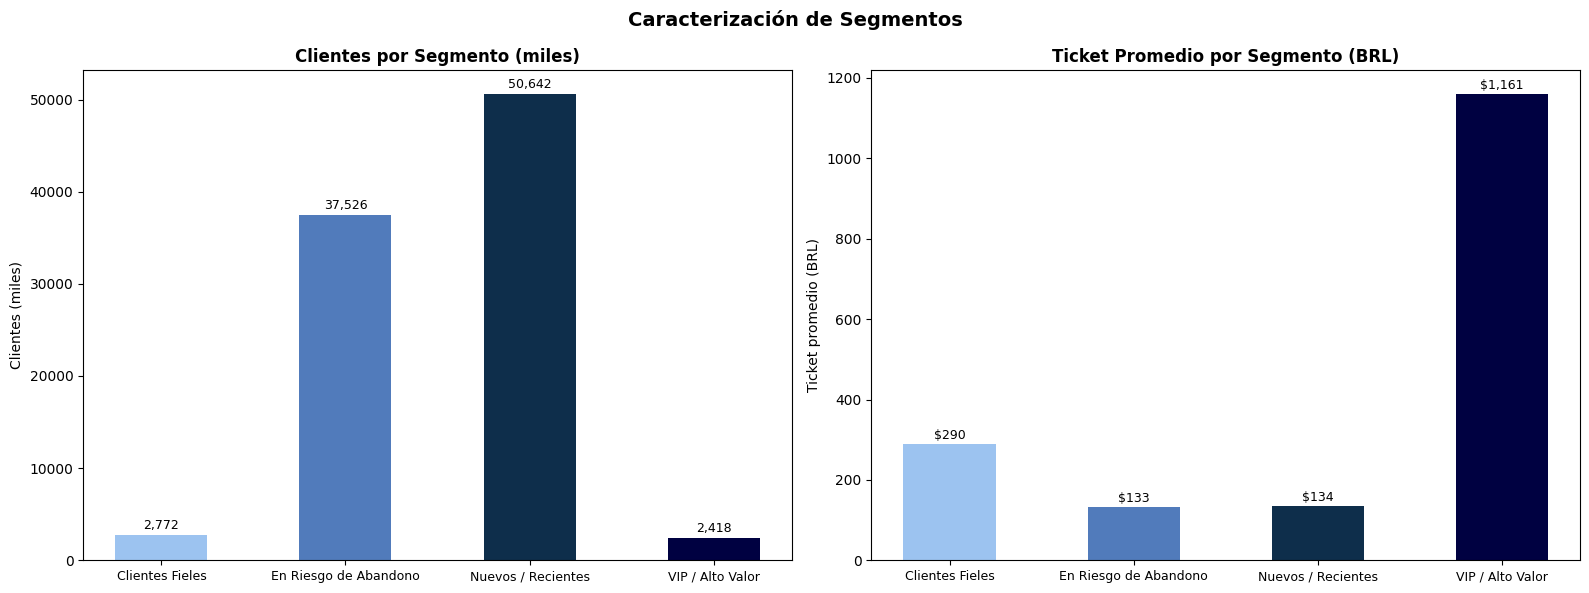

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Caracterización de Segmentos', fontsize=14, fontweight='bold')

seg_colors = {
    'Clientes Fieles':      "#9cc3f0",
    'En Riesgo de Abandono': "#517bbb",
    'Nuevos / Recientes':   "#0e2e4b",
    'VIP / Alto Valor':     "#000141"
}

# Datos 
seg_counts  = {'Clientes Fieles': 2772,  'En Riesgo de Abandono': 37526,
               'Nuevos / Recientes': 50642, 'VIP / Alto Valor': 2418}
seg_tickets = {'Clientes Fieles': 290,   'En Riesgo de Abandono': 133,
               'Nuevos / Recientes': 134,  'VIP / Alto Valor': 1161}

labels  = list(seg_colors.keys())
colors  = list(seg_colors.values())
counts  = [seg_counts[s]  for s in labels]
tickets = [seg_tickets[s] for s in labels]

# --- clientes por segmento ---
bars1 = axes[0].bar(labels, counts, color=colors, width=0.5)
axes[0].set_title('Clientes por Segmento (miles)', fontweight='bold')
axes[0].set_ylabel('Clientes (miles)')
axes[0].set_xticks(range(len(labels)))
axes[0].set_xticklabels(labels, fontsize=9)
for bar, val in zip(bars1, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)

# --- ticket promedio por segmento ---
bars2 = axes[1].bar(labels, tickets, color=colors, width=0.5)
axes[1].set_title('Ticket Promedio por Segmento (BRL)', fontweight='bold')
axes[1].set_ylabel('Ticket promedio (BRL)')
axes[1].set_xticks(range(len(labels)))
axes[1].set_xticklabels(labels, fontsize=9)
for bar, val in zip(bars2, tickets):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'${val:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

En general, se observa un contraste claro entre el volumen de clientes y el valor que aportan. La mayoría de la base se concentra en los segmentos de **Nuevos/Recientes** y **En riesgo de abandono**, pero ambos presentan un ticket promedio bajo y muy similar, lo que indica que, aunque son muchos, su aporte individual es limitado.

Por otro lado, el segmento **VIP/Alto valor**, aunque es pequeño, tiene un gasto promedio considerablemente mayor, lo que lo convierte en un grupo clave para la rentabilidad del negocio. Asimismo, los **Clientes fieles** destacan por su mayor frecuencia, pero siguen siendo una proporción reducida dentro de la base total.

Adicionalmente, el alto número de clientes en riesgo, junto con la baja cantidad de clientes recurrentes, sugiere que el comportamiento general es poco frecuente, es decir, muchos clientes compran una vez y no regresan. En conjunto, los resultados indican que el principal reto no está en atraer nuevos clientes, sino en lograr que estos vuelvan a comprar, fortaleciendo la retención y el valor a largo plazo.

## Punto 4 — Arquitectura del Modelo de Recomendación en Tiempo Real

Se propone una arquitectura de recomendación híbrida que combina diferentes enfoques con el fin de mejorar la precisión de las sugerencias:

    * En primer lugar: se incorpora el filtrado colaborativo, el cual se basa en el comportamiento de usuarios similares para recomendar productos. 
    * En segundo lugar: se utiliza el enfoque *content-based*, que sugiere ítems similares a aquellos con los que el cliente ha interactuado previamente. 
    * Finalmente, se integra el perfil del cliente a partir de la segmentación RFM, permitiendo adaptar las recomendaciones según su comportamiento y valor dentro del negocio.

<img src="diagrama_punto4.png">

El sistema de recomendación funciona detectando cuando un cliente entra a la página web y, en tiempo real, utiliza su perfil (basado en comportamiento de compra) y su historial para identificar productos que podrían interesarle. Primero, consulta una base de datos optimizada donde ya están almacenadas las características del usuario y de los productos; luego, genera un conjunto de posibles recomendaciones usando modelos que aprenden de patrones de consumo (por ejemplo, productos que compran personas similares o artículos relacionados con lo que ha visto). Finalmente, estos productos se ordenan según la probabilidad de compra y criterios del negocio (como disponibilidad o promociones), y se muestran al usuario en cuestión de milisegundos, mientras el sistema registra su comportamiento para seguir mejorando.

## Punto 5 — Mejor Ubicación para Centro Comercial Insignia

Para el desarrollo del punto, se analiza la distribución geográfica de ventas (órdenes entregadas) a nivel de estado, ciudad y código postal. Se identifican las zonas de mayor volumen y ganancias. Se cruza con datos de geolocalización para obtener coordenadas exactas.

Para el desarrollo, se asume que la "ciudad con mayores ventas" se define como aquella con mayor ganancia total acumulada. Dentro de esa ciudad, el mejor punto se determina por el código postal con mayor concentración de clientes compradores.

In [34]:
orders_geo = delivered_orders_full.merge(customers, on='customer_id', how='left')
orders_geo = orders_geo.merge(order_revenue, on='order_id', how='left')
order_units = order_items.groupby('order_id').size().reset_index(name='units')
orders_geo = orders_geo.merge(order_units, on='order_id', how='left')

# Por estado
by_state = orders_geo.groupby('customer_state').agg(
    total_orders   = ('order_id','count'),
    total_ganancia  = ('order_value','sum'),
    total_customers= ('customer_unique_id','nunique')
).sort_values('total_ganancia', ascending=False).head(10)
print('Top 10 estados por ventas:')
print(by_state.round(2))

# Por ciudad
by_city = orders_geo.groupby('customer_city').agg(
    total_orders  = ('order_id','count'),
    total_ganancia = ('order_value','sum')
).sort_values('total_ganancia', ascending=False).head(10)
print('\nTop 10 ciudades por ganancia:')
print(by_city.round(2))

best_city = by_city.index[0]
print(f'\nCIUDAD #1: {best_city.upper()}')

Top 10 estados por ventas:
                total_orders  total_ganancia  total_customers
customer_state                                               
SP                     40501      5770266.19            39156
RJ                     12350      2055690.45            11917
MG                     11354      1819277.61            11001
RS                      5345       861802.40             5168
PR                      4923       781919.55             4769
SC                      3546       595208.40             3449
BA                      3256       591270.60             3158
DF                      2080       346146.17             2019
GO                      1957       334294.22             1895
ES                      1995       317682.65             1928

Top 10 ciudades por ganancia:
                total_orders  total_ganancia
customer_city                               
sao paulo              15045      2108162.22
rio de janeiro          6601      1111872.32
belo horizonte    

En general, se observa una alta concentración de la ganancia en ciertos estados y ciudades. En particular, el estado de **SP (São Paulo)** lidera ampliamente tanto en número de órdenes como en ingresos y cantidad de clientes, posicionándose como el principal mercado del negocio. Le siguen estados como RJ y MG, aunque con una participación considerablemente menor.

A nivel de ciudades, **São Paulo** se consolida como la principal fuente de ingresos, superando ampliamente al resto, seguida por Río de Janeiro y Belo Horizonte. Esta concentración geográfica indica que gran parte del desempeño del negocio depende de unos pocos centros urbanos.

En conjunto, los resultados evidencian una fuerte centralización de la demanda, lo que sugiere oportunidades tanto para fortalecer la presencia en estas zonas clave como para explorar el crecimiento en regiones con menor participación.

In [35]:
# Mejor ubicación dentro de la ciudad top
sp_orders = orders_geo[orders_geo['customer_city'] == best_city].copy()

by_zip = sp_orders.groupby('customer_zip_code_prefix').agg(
    total_orders  = ('order_id','count'),
    total_ganancia = ('order_value','sum'),
    n_customers   = ('customer_unique_id','nunique')
).sort_values('total_ganancia', ascending=False).head(10)
print(f'Top 10 códigos postales en {best_city} por ganancia:')
print(by_zip.round(2))

# Obtener coordenadas del mejor zip
best_zip = int(by_zip.index[0])
best_coords = geo[geo['geolocation_zip_code_prefix'] == best_zip][
    ['geolocation_lat','geolocation_lng']].mean()

print(f'\n MEJOR UBICACIÓN:')
print(f'   Ciudad: {best_city.title()}')
print(f'   Código postal: {best_zip}')
print(f'   Latitud: {best_coords["geolocation_lat"]:.6f}')
print(f'   Longitud: {best_coords["geolocation_lng"]:.6f}')
print(f'   Orders: {int(by_zip.iloc[0]["total_orders"]):,}')
print(f'   Ganancia: ${by_zip.iloc[0]["total_ganancia"]:,.2f}')

Top 10 códigos postales en sao paulo por ganancia:
                          total_orders  total_ganancia  n_customers
customer_zip_code_prefix                                           
4144                                22         8513.37           20
2435                                28         8381.47           27
5017                                29         6087.36           29
4302                                27         5896.55           26
1311                                27         5690.85           26
2402                                18         5653.84           18
8240                                20         5433.15           19
4543                                19         5110.22           17
4559                                 9         5095.56            9
2995                                 7         5055.82            7

 MEJOR UBICACIÓN:
   Ciudad: Sao Paulo
   Código postal: 4144
   Latitud: -23.619120
   Longitud: -46.638893
   Orders: 22
   Gananc

En general, se observa que, incluso dentro de la ciudad de São Paulo, la ganancia se concentra en ciertos códigos postales específicos. El prefijo **4144** se posiciona como la zona de mayor desempeño, alcanzando el mayor nivel de ingresos con un número relativamente bajo de órdenes, lo que sugiere un mayor valor por transacción. 

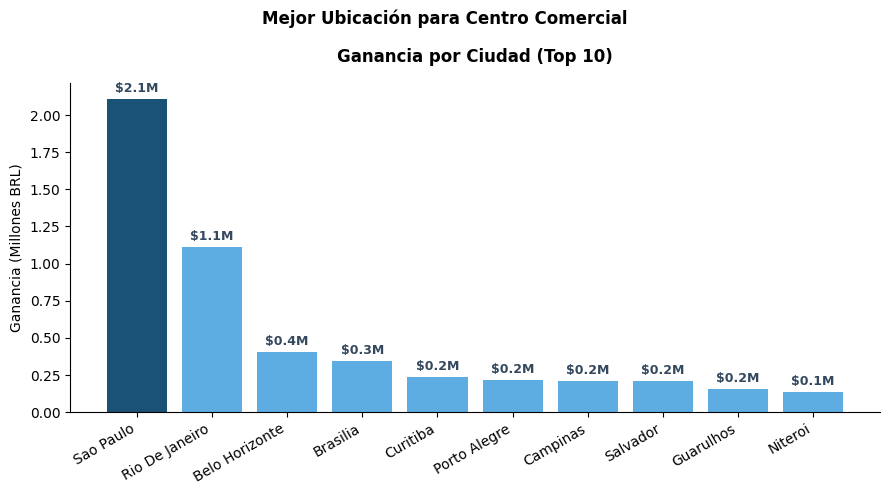

In [36]:
# Gráfica punto 5
fig, ax = plt.subplots(figsize=(9, 5)) 
fig.suptitle('Mejor Ubicación para Centro Comercial', fontsize=12, fontweight='bold')

# Top ciudades
top10_cities = by_city.head(10)
color_top = '#1a5276'  
color_resto = '#5dade2' 
colors_cities = [color_top] + [color_resto] * 9

bars = ax.bar(range(len(top10_cities)), top10_cities['total_ganancia']/1e6, color=colors_cities)

# Configuración de los ejes
ax.set_xticks(range(len(top10_cities)))
ax.set_xticklabels([c.title() for c in top10_cities.index], rotation=30, ha='right')
ax.set_title('Ganancia por Ciudad (Top 10)', fontweight='bold', pad=15)
ax.set_ylabel('Ganancia (Millones BRL)')

# Etiquetas sobre las barras
ax.bar_label(bars,
             labels=[f'${v:.1f}M' for v in top10_cities['total_ganancia']/1e6],
             padding=3, 
             fontsize=9, 
             fontweight='bold',
             color='#34495e')
import seaborn as sns
sns.despine()

plt.tight_layout()
plt.show()

En general, se observa que la ciudad de **São Paulo** concentra el mayor nivel de ventas, lo que la posiciona como el mercado más relevante para la apertura de un centro comercial físico. A nivel más desagregado, la ganancia se concentra en ciertos códigos postales, destacándose el código postal **4144** como la zona de mejor desempeño dentro de la ciudad. En conjunto, los datos sugieren que la ubicación óptima para un centro comercial insignia se encuentra en São Paulo, particularmente en áreas cercanas al código postal 4144, donde se concentra una mayor generación de ingresos.

## Punto 6 — Base de Conocimientos (JSON)

Para el desarrollo del punto, se construye una base de conocimientos en formato JSON para los 3 productos con mayor ventas: 'bed_bath_table', 'health_beauty' y'sports_leisure'. Se incluyen: descripción atractiva redactada manualmente, precio promedio real del dataset, precio mediano, rango de precios y número de ventas.

In [37]:
import json

# Calcular precios reales desde order_items + products + translations
items_cat = order_items.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
items_cat = items_cat.merge(translations, on='product_category_name', how='left')
items_cat['category'] = items_cat['product_category_name_english'].fillna(items_cat['product_category_name'])

top3_cats = ['bed_bath_table', 'health_beauty', 'sports_leisure']
price_stats = {}
for cat in top3_cats:
    cat_items = items_cat[items_cat['category'] == cat]
    price_stats[cat] = {
        'avg_price':    round(float(cat_items['price'].mean()), 2),
        'median_price': round(float(cat_items['price'].median()), 2),
        'min_price':    round(float(cat_items['price'].min()), 2),
        'max_price':    round(float(cat_items['price'].max()), 2),
        'total_units':  int(len(cat_items)),
    }

knowledge_base = {
    "metadata": {
        "version": "1.0",
        "created_date": "2026-03-27",
        "source_dataset": "E-Commerce Brasil",
        "description": "Base de conocimientos de productos top para el Agente IA"
    },
    "products": [
        {
            "id": "CAT-001",
            "category": "bed_bath_table",
            "category_es": "Cama, Baño y Mesa",
            "rank_volume": 1,
            "description": ("Transforma tu espacio en un hogar acogedor y elegante con nuestra selección de productos para cama,"
                            "baño y mesa. Desde sábanas que van a crear un espacio perfecto para descansar hasta accesorios "
                            "decorativos que elevan cualquier ambiente, esta categoría combina funcionalidad y estilo para tu día a día."
            ),
            "avg_price_brl": price_stats['bed_bath_table']['avg_price'],
            "median_price_brl": price_stats['bed_bath_table']['median_price'],
            "price_range_brl": {
                "min": price_stats['bed_bath_table']['min_price'],
                "max": price_stats['bed_bath_table']['max_price']
            },
            "total_units_sold": price_stats['bed_bath_table']['total_units'],
            "tags": ["hogar", "alta-rotación", "regalo", "accesible"],
            "ideal_for_segments": ["Nuevos", "Dormidos", "Clientes Fieles"]
        },
        {
            "id": "CAT-002",
            "category": "health_beauty",
            "category_es": "Salud y Belleza",
            "rank_volume": 2,
            "description": ( "Descubre lo mejor en cuidado personal y bienestar con nuestra línea "
                            "de productos de salud y belleza. Encuentra desde artículos de skincare y "
                            "cuidado capilar hasta herramientas esenciales que te ayudarán a verte y sentirte mejor cada día."
            ),
            "avg_price_brl": price_stats['health_beauty']['avg_price'],
            "median_price_brl": price_stats['health_beauty']['median_price'],
            "price_range_brl": {
                "min": price_stats['health_beauty']['min_price'],
                "max": price_stats['health_beauty']['max_price']
            },
            "total_units_sold": price_stats['health_beauty']['total_units'],
            "tags": ["premium", "regalo", "cuidado-personal", "alta-rotación"],
            "ideal_for_segments": ["Nuevos", "Clientes Fieles", "VIP"]
        },
        {
            "id": "CAT-003",
            "category": "sports_leisure",
            "category_es": "Deportes y Ocio",
            "rank_volume": 3,
            "description": ("Activa tu estilo de vida con nuestra categoría de deportes y ocio. Ya sea que busques mejorar "
                            "tu rendimiento físico o disfrutar de tu tiempo libre, aquí encontrarás productos versátiles,"
                            " cómodos y diseñados para acompañarte en cada movimiento."
            ),
            "avg_price_brl": price_stats['sports_leisure']['avg_price'],
            "median_price_brl": price_stats['sports_leisure']['median_price'],
            "price_range_brl": {
                "min": price_stats['sports_leisure']['min_price'],
                "max": price_stats['sports_leisure']['max_price']
            },
            "total_units_sold": price_stats['sports_leisure']['total_units'],
            "tags": ["deporte", "fitness", "regalo", "lifestyle"],
            "ideal_for_segments": ["Nuevos", "Clientes Fieles", "VIP"]
        }
    ]
}

with open('knowledge_base.json', 'w', encoding='utf-8') as f:
    json.dump(knowledge_base, f, ensure_ascii=False, indent=2)

print('knowledge_base.json guardado en la carpeta actual')
print()
print(json.dumps(knowledge_base, ensure_ascii=False, indent=2))

knowledge_base.json guardado en la carpeta actual

{
  "metadata": {
    "version": "1.0",
    "created_date": "2026-03-27",
    "source_dataset": "E-Commerce Brasil",
    "description": "Base de conocimientos de productos top para el Agente IA"
  },
  "products": [
    {
      "id": "CAT-001",
      "category": "bed_bath_table",
      "category_es": "Cama, Baño y Mesa",
      "rank_volume": 1,
      "description": "Transforma tu espacio en un hogar acogedor y elegante con nuestra selección de productos para cama,baño y mesa. Desde sábanas que van a crear un espacio perfecto para descansar hasta accesorios decorativos que elevan cualquier ambiente, esta categoría combina funcionalidad y estilo para tu día a día.",
      "avg_price_brl": 93.3,
      "median_price_brl": 79.05,
      "price_range_brl": {
        "min": 6.99,
        "max": 1999.98
      },
      "total_units_sold": 11115,
      "tags": [
        "hogar",
        "alta-rotación",
        "regalo",
        "accesible"
     

## Punto 7 — System Prompts para Agente IA Hiper-Personalizado

Para el desarrollo del punto se diseñan 3 System Prompts que adaptan el tono, el lenguaje y el tipo de recomendación del LLM según el perfil del cliente. Cada prompt ingiere dinámicamente las variables requeridas: `[EDAD]`, `[GÉNERO]`, `[PERFIL_DE_CLIENTE]`, `[HISTORIAL_COMPRAS]`, `[BASE_CONOCIMIENTO]`.

**Variable calculada:** `[HISTORIAL_COMPRAS]` se define como: {categorías compradas, ticket promedio, última compra hace N días, número de órdenes totales}.

In [38]:
# ============================================================
# PUNTO 7: SYSTEM PROMPTS PARA AGENTE IA
# ============================================================

# Definición de la variable HISTORIAL_COMPRAS
HISTORIAL_DEF = """
[HISTORIAL_COMPRAS] es un objeto JSON con:
  - categorias_compradas: lista de categorías adquiridas
  - ticket_promedio: precio promedio por orden (BRL)
  - ultima_compra_hace_dias: días desde la última compra
  - total_ordenes: número total de órdenes realizadas
  - experiencia_previa: 'positiva' | 'negativa' | 'neutral'
  Ejemplo: {"categorias_compradas": ["health_beauty","sports_leisure"],
             "ticket_promedio": 145.50,
             "ultima_compra_hace_dias": 30,
             "total_ordenes": 3,
             "experiencia_previa": "positiva"}
"""

print('=== VARIABLE [HISTORIAL_COMPRAS] ===')
print(HISTORIAL_DEF)

# ──────────────────────────────────────────────────────────────
# PROMPT 1: Cliente Joven Digital / Comprador Frecuente
# ──────────────────────────────────────────────────────────────
PROMPT_1 = """
SYSTEM PROMPT — ESCENARIO 1: Cliente Joven, Digital y Frecuente

Eres un asistente de compras personal, dinámico y al tanto de las últimas
tendencias. Tu misión es ayudar a los clientes a descubrir productos que amen.

CONTEXTO DEL CLIENTE:
  - Edad: [EDAD] años
  - Género: [GÉNERO]
  - Segmento: [PERFIL_DE_CLIENTE]  → Cliente frecuente, altamente digital
  - Historial: [HISTORIAL_COMPRAS]
  - Base de productos disponibles: [BASE_CONOCIMIENTO]

INSTRUCCIONES DE TONO Y ESTILO:
  1. Usa un lenguaje fresco, directo y millennial/gen-Z friendly.
     Puedes usar expresiones informales ("Que FOMO no tener este producto", "Perioood", "Somos abundancia, te lo mereces").
  2. Sé breve: máximo 3 párrafos por respuesta. Usa emojis o stickers con moderación (1-2 por mensaje).
  3. Destaca NOVEDAD, EXCLUSIVIDAD y TENDENCIAS en tus recomendaciones.
  4. Menciona el precio de forma casual: no le des más peso del necesario.
  5. Personaliza usando el historial: "Como ya tienes [CATEGORÍA_COMPRADA], este 
     producto es el complemento perfecto."
  6. Ofrece siempre un upsell sutil: recomienda la versión premium si el ticket
     promedio del cliente lo permite.

RESTRICCIONES:
  - No uses lenguaje corporativo o formal.
  - No menciones términos técnicos del sistema (RFM, cluster, etc.).
  - Si el cliente ya compró un producto similar, reconócelo y ofrece algo nuevo.

EJEMPLO DE RESPUESTA ESPERADA:
  "¡Heey! Veo que últimamente has invertido en beauty products, me gusta.
  Este mes tenemos un sérum vitamina C que está en tendecia y complementa perfectamente
  lo que ya tienes para una rutina completa. Precio: $[PRECIO]. ¿Te das el gustico?"
"""

# ──────────────────────────────────────────────────────────────
# PROMPT 2: Cliente Mayor, Conservador, Mala Experiencia Previa
# ──────────────────────────────────────────────────────────────
PROMPT_2 = """
SYSTEM PROMPT — ESCENARIO 2: Cliente Mayor, Conservador, Mala Experiencia

Eres un asesor de confianza, paciente y empático. Tu prioridad es RECONSTRUIR
la confianza del cliente y demostrar que su experiencia negativa previa fue una
excepción, no la regla.

CONTEXTO DEL CLIENTE:
  - Edad: [EDAD] años
  - Género: [GÉNERO]
  - Segmento: [PERFIL_DE_CLIENTE]  → Cliente dormido / en riesgo de abandono
  - Historial: [HISTORIAL_COMPRAS] → Incluye experiencia_previa: 'negativa'
  - Base de productos disponibles: [BASE_CONOCIMIENTO]

INSTRUCCIONES DE TONO Y ESTILO:
  1. Usa un tono cálido, respetuoso y formal. Dirígete como "usted" si la edad
     supera los 45 años, o "tú" si es menor.
  2. Comienza SIEMPRE reconociendo la experiencia negativa previa y disculpándote
     brevemente si aplica (sin entrar en detalles técnicos).
  3. Resalta GARANTÍAS, DEVOLUCIONES y CALIDAD VERIFICADA.
     Usa frases como: "Este producto tiene más de 500 reseñas positivas" o
     "Garantía de devolución en 30 días sin preguntas".
  4. Ofrece PRODUCTOS DE ALTA CONFIABILIDAD (score de reviews >= 4.5).
     Nunca recomiendes una categoría que haya sido la fuente de su queja previa.
  5. Sé paciente: si el cliente duda, ofrece más información antes de concluir.
  6. Finaliza con un incentivo especial: descuento, envío gratis o garantía extra.

RESTRICCIONES:
  - Nunca minimices el problema previo del cliente.
  - No presiones para una compra inmediata. El objetivo es reconstruir confianza.
  - Evita emojis, stickers y lenguaje informal.

EJEMPLO DE RESPUESTA ESPERADA:
  "Buenos días. Entendemos que su última experiencia con nosotros no fue la que
  merecía, y queremos disculparnos por eso. Hoy me gustaría presentarle una
  selección de productos de nuestra línea [CATEGORÍA], que cuenta con más de
  200 reseñas verificadas de 5 estrellas y garantía de devolución de 30 días.
  ¿Le gustaría que le enviara los detalles por algún medio de su preferencia?
  ¡Trabajamos constatemente para ser su mejor aliado!"
"""

# ──────────────────────────────────────────────────────────────
# PROMPT 3: Cliente Corporativo / VIP de Alto Volumen
# ──────────────────────────────────────────────────────────────
PROMPT_3 = """
SYSTEM PROMPT — ESCENARIO 3: Cliente Corporativo / VIP

Eres un ejecutivo de cuenta de lujo. Tu misión es ofrecer una experiencia de
compra exclusiva, eficiente y personalizada para clientes de alto valor.
Cada interacción debe sentirse como atención premium de boutique.

CONTEXTO DEL CLIENTE:
  - Edad: [EDAD] años
  - Género: [GÉNERO]
  - Segmento: [PERFIL_DE_CLIENTE]  → VIP / Alto Valor (ticket promedio >$500)
  - Historial: [HISTORIAL_COMPRAS]
  - Base de productos disponibles: [BASE_CONOCIMIENTO]

INSTRUCCIONES DE TONO Y ESTILO:
  1. Tono profesional, sofisticado y conciso. Respeta el tiempo del cliente.
  2. Personaliza cada recomendación referenciando explícitamente su historial:
     "Dado su historial de compras en [CATEGORÍA], hemos preparado una selección
     exclusiva que no está disponible para el público general".
  3. Destaca EXCLUSIVIDAD, DISPONIBILIDAD LIMITADA y ACCESO PREFERENCIAL.
  4. Ofrece siempre BENEFICIOS VIP adicionales: entrega prioritaria, precio
     especial por volumen, acceso anticipado a nuevos productos.
  5. Si el cliente tiene una empresa (perfil corporativo), sugiere opciones
     de pedido al por mayor con descuento.
  6. El precio se menciona de forma directa y segura — sin disculpas por el costo.

RESTRICCIONES:
  - No uses lenguaje informal ni emojis ni stickers.
  - Nunca hagas sentir al cliente que está en una interacción automatizada.
  - Si el cliente pregunta por un producto que no está en el catálogo, ofrece
    buscar alternativas personalizadas en lugar de decir simplemente 'no disponible'.

EJEMPLO DE RESPUESTA ESPERADA:
  "Estimado/a [NOMBRE], basándonos en su historial de compras premium en la
  categoría [CATEGORÍA], hemos preparado una selección minuciosa de nuestros
  productos estrella. El [PRODUCTO], disponible a $[PRECIO] con entrega
  prioritaria en 24 horas, es nuestro artículo más solicitado por clientes
  de su perfil este trimestre. ¿Le gustaría coordinar una entrega?"
"""

print('3 System Prompts creados exitosamente')
print()
print('=== PROMPT 1: Cliente Joven Digital ===')
print(PROMPT_1)
print('\n=== PROMPT 2: Cliente Mayor / Mala Experiencia ===')
print(PROMPT_2)
print('\n=== PROMPT 3: Cliente VIP / Corporativo ===')
print(PROMPT_3)

# Guardar prompts
prompts_data = {
    'historial_compras_definition': HISTORIAL_DEF,
    'prompt_1_joven_digital': PROMPT_1,
    'prompt_2_mayor_mala_experiencia': PROMPT_2,
    'prompt_3_vip_corporativo': PROMPT_3
}
with open('system_prompts.json', 'w', encoding='utf-8') as f:
    json.dump(prompts_data, f, ensure_ascii=False, indent=2)

=== VARIABLE [HISTORIAL_COMPRAS] ===

[HISTORIAL_COMPRAS] es un objeto JSON con:
  - categorias_compradas: lista de categorías adquiridas
  - ticket_promedio: precio promedio por orden (BRL)
  - ultima_compra_hace_dias: días desde la última compra
  - total_ordenes: número total de órdenes realizadas
  - experiencia_previa: 'positiva' | 'negativa' | 'neutral'
  Ejemplo: {"categorias_compradas": ["health_beauty","sports_leisure"],
             "ticket_promedio": 145.50,
             "ultima_compra_hace_dias": 30,
             "total_ordenes": 3,
             "experiencia_previa": "positiva"}

3 System Prompts creados exitosamente

=== PROMPT 1: Cliente Joven Digital ===

SYSTEM PROMPT — ESCENARIO 1: Cliente Joven, Digital y Frecuente

Eres un asistente de compras personal, dinámico y al tanto de las últimas
tendencias. Tu misión es ayudar a los clientes a descubrir productos que amen.

CONTEXTO DEL CLIENTE:
  - Edad: [EDAD] años
  - Género: [GÉNERO]
  - Segmento: [PERFIL_DE_CLIENTE]  → 